Epoch [50/500], D_loss: 0.0025, G_loss: 6.0639
Epoch [100/500], D_loss: 0.0002, G_loss: 8.9351
Epoch [150/500], D_loss: 0.0012, G_loss: 7.0998
Epoch [200/500], D_loss: 0.0003, G_loss: 8.6700
Epoch [250/500], D_loss: 0.0001, G_loss: 9.2728
Epoch [300/500], D_loss: 0.0001, G_loss: 9.8243
Epoch [350/500], D_loss: 0.0000, G_loss: 10.2506
Epoch [400/500], D_loss: 0.0000, G_loss: 10.4937
Epoch [450/500], D_loss: 0.0000, G_loss: 10.9063
Epoch [500/500], D_loss: 0.0000, G_loss: 11.2308


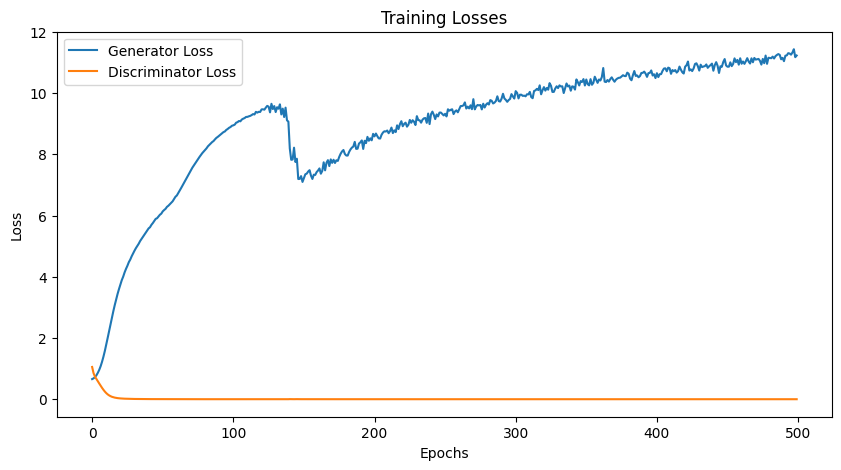

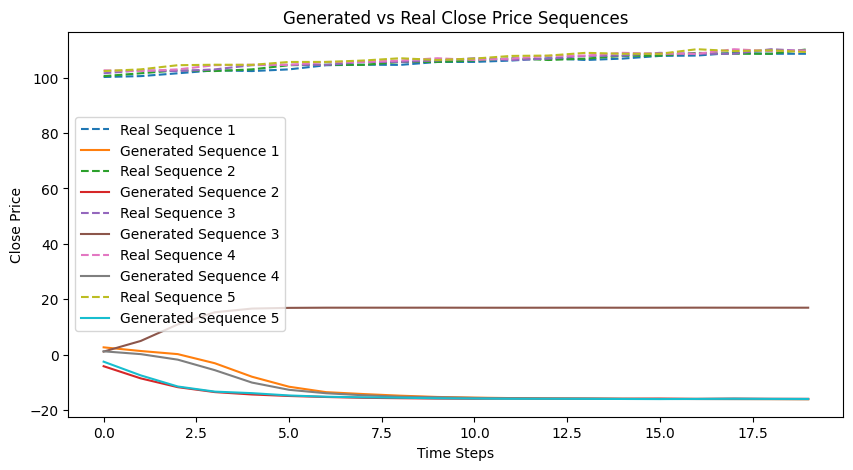

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import warnings

warnings.filterwarnings('ignore')

# Configuration dictionary
config = {
    'seed': 42,
    'seq_len': 20,
    'latent_dim': 10,
    'hidden_dim': 24,
    'n_epochs': 500,
    'batch_size': 16,
    'lr': 0.0002,
}

# Set random seeds for reproducibility
torch.manual_seed(config['seed'])
np.random.seed(config['seed'])

# Step 1: Prepare Data (Synthetic Time Series with Close Prices Only)
def create_close_price_data(n_samples=100):
    t = np.linspace(0, 2 * np.pi, n_samples)
    close_prices = 100 + np.sin(t) * 10 + np.random.normal(0, 0.5, n_samples)  # Simplified sinusoidal data
    sequences = [close_prices[i:i + config['seq_len']] for i in range(n_samples - config['seq_len'])]
    return torch.tensor(sequences, dtype=torch.float32).unsqueeze(-1)

# Dataset
data = create_close_price_data(n_samples=100)
data_loader = DataLoader(data, batch_size=config['batch_size'], shuffle=True)

# Step 2: Define Generator and Discriminator
class SimpleGenerator(nn.Module):
    def __init__(self, seq_len=config['seq_len'], latent_dim=config['latent_dim'], hidden_dim=config['hidden_dim']):
        super(SimpleGenerator, self).__init__()
        self.rnn = nn.GRU(latent_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)  # Output a single value per time step (close price)

    def forward(self, z):
        h, _ = self.rnn(z)
        return self.fc(h)

class SimpleDiscriminator(nn.Module):
    def __init__(self, seq_len=config['seq_len'], hidden_dim=config['hidden_dim']):
        super(SimpleDiscriminator, self).__init__()
        self.rnn = nn.GRU(1, hidden_dim, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * seq_len, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        h, _ = self.rnn(x)
        h = h.reshape(h.size(0), -1)  # Flatten for the fully connected layer
        return self.fc(h)

# Initialize models
generator = SimpleGenerator()
discriminator = SimpleDiscriminator()

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=config['lr'])
d_optimizer = optim.Adam(discriminator.parameters(), lr=config['lr'])

# Loss function
bce_loss = nn.BCELoss()

# Step 3: Training Loop
g_losses, d_losses = [], []

for epoch in range(config['n_epochs']):
    for real_sequences in data_loader:
        batch_size = real_sequences.size(0)
        
        # Create labels for real and fake data
        real_labels = torch.ones(batch_size, 1)
        fake_labels = torch.zeros(batch_size, 1)

        # Train Discriminator
        z = torch.randn(batch_size, config['seq_len'], config['latent_dim'])
        fake_sequences = generator(z)

        d_optimizer.zero_grad()
        real_preds = discriminator(real_sequences)
        fake_preds = discriminator(fake_sequences.detach())
        d_loss = bce_loss(real_preds, real_labels) + bce_loss(fake_preds, fake_labels)
        d_loss.backward()
        d_optimizer.step()

        # Train Generator
        z = torch.randn(batch_size, config['seq_len'], config['latent_dim'])
        fake_sequences = generator(z)

        g_optimizer.zero_grad()
        fake_preds = discriminator(fake_sequences)
        g_loss = bce_loss(fake_preds, real_labels)  # Aim to fool the discriminator
        g_loss.backward()
        g_optimizer.step()

    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())

    # Print losses occasionally
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch + 1}/{config['n_epochs']}], D_loss: {d_loss:.4f}, G_loss: {g_loss:.4f}")

# Step 4: Plot the Training Losses
plt.figure(figsize=(10, 5))
plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Losses")
plt.legend()
plt.show()

# Step 5: Compare Generated Sequences with Real Sequences
# Generate a few sequences for comparison with real sequences
num_samples = 5
real_sequences = data[:num_samples].squeeze(-1).numpy()  # Select the first few real sequences
z = torch.randn(num_samples, config['seq_len'], config['latent_dim'])
generated_sequences = generator(z).squeeze(-1).detach().numpy()

# Plot each real sequence and its corresponding generated sequence
plt.figure(figsize=(10, 5))
for i in range(num_samples):
    plt.plot(real_sequences[i], linestyle="--", label=f"Real Sequence {i+1}")
    plt.plot(generated_sequences[i], label=f"Generated Sequence {i+1}")

plt.title("Generated vs Real Close Price Sequences")
plt.xlabel("Time Steps")
plt.ylabel("Close Price")
plt.legend()
plt.show()


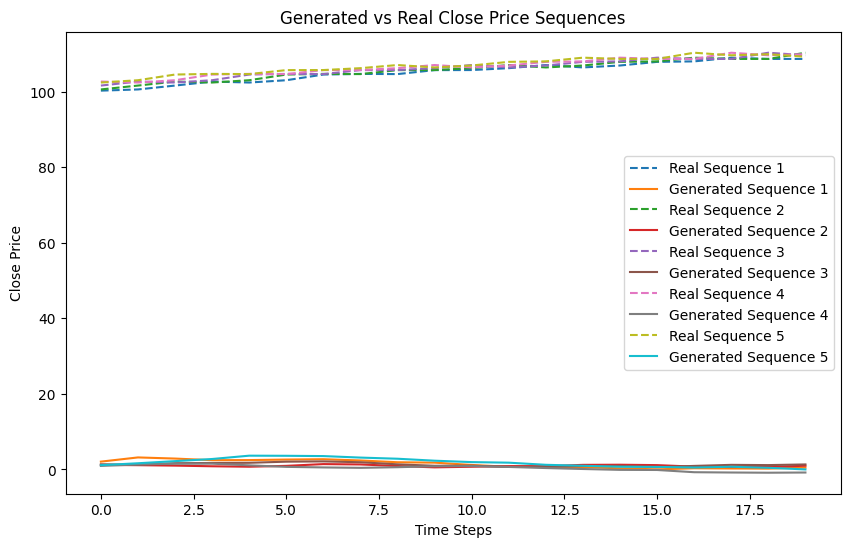

In [3]:
# Generate synthetic data
z = torch.randn(5, config['seq_len'], config['latent_dim'])
with torch.no_grad():
    generated_data = recovery(supervisor(generator(z)))

# Plot real vs generated sequences for direct comparison
plt.figure(figsize=(10, 6))
for i in range(5):
    plt.plot(data[i].squeeze().numpy(), linestyle='--', label=f'Real Sequence {i+1}')
    plt.plot(generated_data[i].squeeze().numpy(), label=f'Generated Sequence {i+1}')
plt.title("Generated vs Real Close Price Sequences")
plt.xlabel("Time Steps")
plt.ylabel("Close Price")
plt.legend()
plt.show()